# The Tangency Portfolio
Now add a risk-free asset. This is what turns the curved frontier into the practical workhorse and gives you the max-Sharpe portfolio.

In [1]:
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [2]:
mu = np.array([0.3, 0.5, 0.2])
sigma = np.array([
    [0.10, 0.02, 0.04],
    [0.02, 0.08, 0.01],
    [0.04, 0.01, 0.12]
])

**Adding the risk-free asset.** Suppose you can borrow/lend at rate $r_f$. Now a portfolio can mix the risk-free asset with any risky portfolio. If you put fraction $\alpha$ in a risky portfolio $p$ and $1-\alpha$ in the risk-free asset:

$$
\mu = r_f + \alpha(\mu_p - r_f), \qquad \sigma = \alpha\sigma_p
$$

Both are linear in $\alpha$ — so in (risk, return) space this traces a **straight line** from $(0, r_f)$  through the risky portfolio $p$. Different risky portfolios give different lines. With a risk-free asset available, every achievable risk-return combination lies on some straight line from $(0, r_f)$ through a risky portfolio.

**The Capital Market Line.** Among all those lines, you (rational investor) want the steepest — the one giving the most return per unit of risk. The steepest line from $(0, r_f)$ that still touches the efficient frontier is **tangent** to the frontier at exactly one point. That tangency point is the **tangency portfolio** $w_T$. The line itself is the **Capital Market Line (CML)**.

**The tangency portfolio maximizes the Sharpe ratio.** The slope of any line from $(0, r_f)$ through a risky portfolio is:

$$
\text{slope} = \frac{\mu_p - r_f}{\sigma_p} = \text{Sharpe ratio}
$$

The steepest line = highest Sharpe = tangency point. So the tangency portfolio is the max-Sharpe portfolio.

**The closed form** (with risk-free asset, this is clean):

$$
w_T = \frac{\Sigma^{-1}(\mu - r_f\mathbf{1})}{\mathbf{1}^T\Sigma^{-1}(\mu - r_f\mathbf{1})}
$$

The numerator $\Sigma^{-1}(\mu - r_f\mathbf{1})$ is the key object — risk-adjusted excess returns. The denominator just normalizes weights to sum to 1. Notice $\Sigma^{-1}$ again — every Markowitz quantity runs through the inverse covariance.

In [3]:
def tangency_portfolio(mu, sigma, rf=0.0):
    """
    Closed-form tangency (max-Sharpe) portfolio weights.

        w_T = Σ⁻¹(μ - rf·1) / [1ᵀ Σ⁻¹(μ - rf·1)]

    Requires at least one asset with positive excess return (μᵢ > rf),
    otherwise the tangency portfolio is degenerate.
    Allows short positions.
    """
    mu = np.asarray(mu, dtype=float).ravel()
    excess = mu - rf

    if not np.any(excess > 0):
        raise ValueError("all excess returns are non-positive; tangency portfolio is degenerate")

    z = np.linalg.solve(sigma, excess)   # Σ⁻¹(μ - rf·1)
    return z / z.sum()                   # normalize to budget = 1

tangency_portfolio(mu, sigma, rf=0.05)

array([0.18721461, 0.75799087, 0.05479452])

**Formulating max-Sharpe for the solver**. The Sharpe ratio $\frac{\mu^Tw - r_f}{\sqrt{w^T\Sigma w}}$ is a *ratio* — not a QP, not even convex as written. The standard trick to make it solvable:

$$
\min_w {(\mu-r_f\mathbf{1})^T\omega \over \sqrt{(w^T\Sigma w)}}
$$

Fix the numerator to a constant (say $(\mu - r_f\mathbf{1})^Tw = 1$) and *minimize the denominator*:

$$
\min_w w^T\Sigma w \quad \text{s.t.} \quad (\mu - r_f\mathbf{1})^Tw = 1
$$

This is a clean QP. Solve it, then rescale $w$ so the weights sum to 1. **Maximizing a ratio becomes minimizing the denominator with the numerator pinned** — the same reformulation that shows up throughout convex optimization for ratio objectives.

In [4]:
def max_sharpe(mu, sigma, rf=0.0, long_only=True):
    """
    Tangency portfolio via the pinned-numerator reformulation.
        min  w^T Sigma w
        s.t. (mu - rf*1)^T w = 1
    then rescale w to sum to 1.
    """
    n = len(mu)
    w = cp.Variable(n)
    excess = mu - rf * np.ones(n)

    objective = cp.Minimize(cp.quad_form(w, cp.psd_wrap(sigma)))
    constraints = [excess @ w == 1]          # pin the numerator
    if long_only:
        constraints.append(w >= 0)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise ValueError(f"solve failed: {prob.status}")
    w_raw = w.value
    return w_raw / w_raw.sum()                # rescale to budget = 1
w = max_sharpe(mu, sigma, rf=0.05)
print(w)

[0.18721461 0.75799087 0.05479452]


One thing worth noting about this formulation, connecting to the theory: notice there's **no budget constraint** $\mathbf{1}^Tw = 1$ inside the solve — you pin the excess-return numerator instead, then rescale at the end. That's the whole trick. The budget constraint is restored by the final normalization. If you tried to impose *both* the pinned numerator and the budget constraint simultaneously, you'd over-constrain the problem (two equality constraints fixing scale in conflicting ways) and likely get infeasibility. So the structure is deliberately: pin numerator → solve → rescale. Don't add the budget line inside.

This clean reformulation assumes there *is* a risk-free asset and that the tangency portfolio is well-defined. If your excess returns $\mu - r_f\mathbf{1}$ are all negative (every asset expected to underperform cash), the tangency portfolio is degenerate and the rescaling can flip signs on you. Worth an assertion or at least a comment. And with `long_only=True`, the pinned-numerator + non-negativity combination can occasionally be infeasible if no long-only portfolio has positive excess return — another reason to check `prob.status`.

**The Two-Fund Separation with a risk-free asset** — the punchline. Every investor, regardless of risk appetite, holds the same tangency portfolio $w_T$; they only differ in how much they split between $w_T$ and the risk-free asset. Aggressive investors lever up the tangency portfolio; conservative ones hold mostly cash plus a little $w_T$. The risky composition is identical for everyone. This is the theoretical seed of CAPM — if everyone holds the same risky portfolio, in equilibrium that portfolio must be the market, which is the reverse-optimization logic Black-Litterman uses to extract $\Pi$.

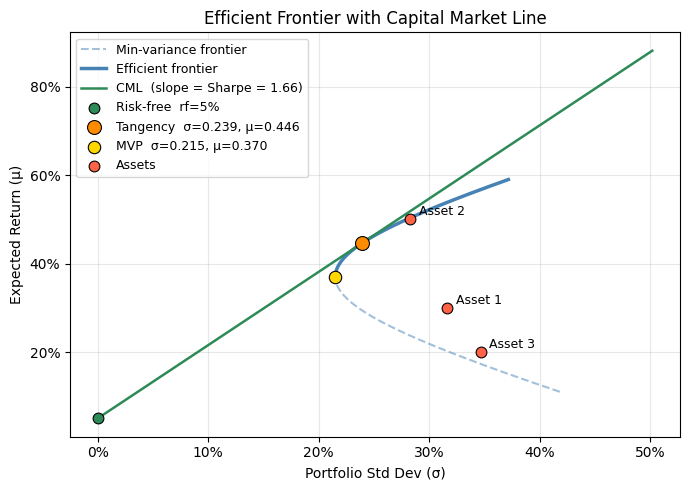

In [5]:
def plot_tangency_portfolio(mu, sigma, rf=0.05, n_points=500, ax=None):
    mu = np.asarray(mu, dtype=float).ravel()
    sigma = np.asarray(sigma, dtype=float)
    ones = np.ones(len(mu))

    # Frontier scalars
    x = np.linalg.solve(sigma, mu)
    y = np.linalg.solve(sigma, ones)
    A = ones @ y
    B = ones @ x
    C = mu @ x
    D = A * C - B ** 2

    mu_mvp  = B / A
    std_mvp = 1.0 / np.sqrt(A)

    mu_grid = np.linspace(mu.min() - 0.3 * (mu.max() - mu.min()),
                          mu.max() + 0.3 * (mu.max() - mu.min()), n_points)
    stds = np.sqrt((A * mu_grid**2 - 2 * B * mu_grid + C) / D)

    # Tangency portfolio
    excess = mu - rf
    z = np.linalg.solve(sigma, excess)
    w_T   = z / z.sum()
    mu_T  = float(w_T @ mu)
    std_T = float(np.sqrt(w_T @ sigma @ w_T))
    sharpe_T = (mu_T - rf) / std_T

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    # Frontier
    ax.plot(stds, mu_grid, color="steelblue", lw=1.5, ls="--", alpha=0.5,
            label="Min-variance frontier")
    eff = mu_grid >= mu_mvp
    ax.plot(stds[eff], mu_grid[eff], color="steelblue", lw=2.5,
            label="Efficient frontier")

    # Capital Market Line: μ = rf + Sharpe_T * σ, from 0 to beyond the frontier
    cml_std = np.linspace(0, stds.max() * 1.2, 200)
    cml_mu  = rf + sharpe_T * cml_std
    ax.plot(cml_std, cml_mu, color="seagreen", lw=1.8, ls="-",
            label=f"CML  (slope = Sharpe = {sharpe_T:.2f})")

    # Risk-free rate anchor
    ax.scatter(0, rf, s=60, zorder=5, color="seagreen", edgecolors="k",
               lw=0.8, label=f"Risk-free  rf={rf:.0%}")

    # Tangency portfolio
    ax.scatter(std_T, mu_T, s=100, zorder=6, color="darkorange", edgecolors="k",
               lw=0.8, label=f"Tangency  σ={std_T:.3f}, μ={mu_T:.3f}")

    # MVP
    ax.scatter(std_mvp, mu_mvp, s=80, zorder=5, color="gold", edgecolors="k",
               lw=0.8, label=f"MVP  σ={std_mvp:.3f}, μ={mu_mvp:.3f}")

    # Individual assets
    asset_stds = np.sqrt(np.diag(sigma))
    ax.scatter(asset_stds, mu, s=60, zorder=5, color="tomato", edgecolors="k",
               lw=0.8, label="Assets")
    for i, (s, r) in enumerate(zip(asset_stds, mu)):
        ax.annotate(f"Asset {i+1}", (s, r), textcoords="offset points",
                    xytext=(6, 3), fontsize=9)

    ax.set_xlabel("Portfolio Std Dev (σ)")
    ax.set_ylabel("Expected Return (μ)")
    ax.set_title("Efficient Frontier with Capital Market Line")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return ax

plot_tangency_portfolio(mu, sigma, rf=0.05)
plt.show()